In [18]:
import wandb
import pandas as pd
import ICIW_Plots
import matplotlib.pyplot as plt
from wandb_util import extract_run_data

plt.style.use("ICIWstyle")
plt.rcParams["font.size"] = 7

In [19]:
run_id = "nx6hue2t"
run_url = f"ice_ulm/HSA_MGA_nRTD/{run_id}"

In [20]:
api = wandb.Api()
run = api.run(run_url)

In [21]:
run_name, run_data = extract_run_data(run_url)
print(run_data)

              name  epoch  lr-Adam  train/loss  trainer/global_step  \
0  snowy-totem-211  19999    0.004    0.000006                19999   

          kernel_sizes                          kernel_times  learning_rate  \
0  [121, 161, 61, 121]  [[0, 30], [0, 40], [0, 15], [0, 30]]          0.004   

   use_scheduler                   scheduler_kwargs  
0          False  {'factor': 0.6, 'patience': 2000}  


In [22]:
orig_data = pd.DataFrame(run.scan_history(keys=["train/loss", "epoch"]))

In [23]:
data = orig_data.copy()
data.loc[400:, "epoch"] += 20000
data.loc[800:, "epoch"] += 20000
data.loc[1200:, "epoch"] += 20000

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


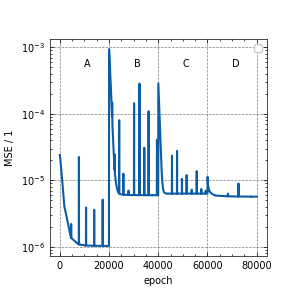

In [27]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel="epoch",
    ylabel="MSE / 1",
    yscale="log",
)
ax.plot(data["epoch"], data["train/loss"])
# ax.plot(data.loc[-1, "epoch"], run_data["test/loss"], "o")
ax.text(10000, 5e-4, "A")
ax.text(30000, 5e-4, "B")
ax.text(50000, 5e-4, "C")
ax.text(70000, 5e-4, "D")
ax.legend()
plt.savefig("1bar_loss.png", dpi=600)